In [2]:

import zipfile
import os

# Path sudah disesuaikan dengan lokasi file kamu
zip_path = '../../archive.zip'
extract_path = '../../'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Lihat file apa saja yang ada setelah di-extract
print("📁 File dalam dataset:")
for f in os.listdir(extract_path):
    print(f"   {f}")

📁 File dalam dataset:
   archive.zip
   DarkModeUI
   DarkModeUI.zip
   judol-detector
   PRD_Judol_Detector.md
   rawdata.csv
   stitch.zip


In [4]:
import pandas as pd

# Load CSV (sesuaikan nama file setelah lihat hasil Cell 2)
# Nanti ganti 'NAMA_FILE.csv' dengan nama file asli yang muncul
df = pd.read_csv('../../rawdata.csv')

print("=" * 50)
print("📊 INFO DATASET KAGGLE")
print("=" * 50)
print(f"Jumlah data  : {len(df)}")
print(f"Jumlah kolom : {len(df.columns)}")
print(f"Nama kolom   : {df.columns.tolist()}")
print(f"\nPreview 5 data pertama:")
df.head()

📊 INFO DATASET KAGGLE
Jumlah data  : 4720
Jumlah kolom : 2
Nama kolom   : ['Label', 'Comments']

Preview 5 data pertama:


,Label,Comments
0,0,Lah ke sol*r*a yg nunggu 1 jam aja masih gw tu...
1,0,"Waktu tunggu normal kok, kalau gak mau ngantri..."
2,0,Murah sih daripada bakso tetelan di atas tadi ...
3,0,emang dasar konsumen masih banyak yg ga sabara...
4,0,15 menit mah bentar banget😂


In [5]:
# Sesuaikan kolom asli 'Comments' dan 'Label' ke format kita
df_bersih = pd.DataFrame({
    'teks': df['Comments'],
    'label': df['Label']
})

# Pastikan label bertipe integer
df_bersih['label'] = df_bersih['label'].astype(int)

print("=" * 50)
print("📊 INFO DATASET")
print("=" * 50)
print(f"Total data   : {len(df_bersih)}")
print(f"Normal   (0) : {len(df_bersih[df_bersih['label']==0])}")
print(f"Judi     (1) : {len(df_bersih[df_bersih['label']==1])}")
print(f"\nPreview:")
df_bersih.head()

📊 INFO DATASET
Total data   : 4720
Normal   (0) : 1187
Judi     (1) : 3533

Preview:


,teks,label
0,Lah ke sol*r*a yg nunggu 1 jam aja masih gw tu...,0
1,"Waktu tunggu normal kok, kalau gak mau ngantri...",0
2,Murah sih daripada bakso tetelan di atas tadi ...,0
3,emang dasar konsumen masih banyak yg ga sabara...,0
4,15 menit mah bentar banget😂,0


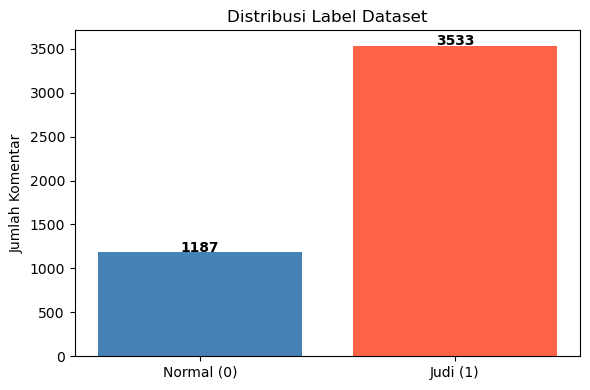

⚠️  Data tidak seimbang! Tapi tetap bisa lanjut.


In [6]:
import matplotlib.pyplot as plt

counts = [
    len(df_bersih[df_bersih['label']==0]),
    len(df_bersih[df_bersih['label']==1])
]

plt.figure(figsize=(6,4))
plt.bar(['Normal (0)', 'Judi (1)'], counts, color=['steelblue','tomato'])
plt.title('Distribusi Label Dataset')
plt.ylabel('Jumlah Komentar')
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

if counts[0] > counts[1] * 2 or counts[1] > counts[0] * 2:
    print("⚠️  Data tidak seimbang! Tapi tetap bisa lanjut.")
else:
    print("✅ Distribusi data seimbang!")

In [7]:
import os
os.makedirs('../dataset', exist_ok=True)

output_path = '../dataset/komentar.csv'
df_bersih.to_csv(output_path, index=False)

print("=" * 50)
print("✅ DATASET BERHASIL DISIMPAN!")
print("=" * 50)
print(f"📁 Lokasi : {output_path}")
print(f"📊 Total  : {len(df_bersih)} komentar")
print(f"\n➡️  Lanjut ke notebook: 01_preprocessing.ipynb")

✅ DATASET BERHASIL DISIMPAN!
📁 Lokasi : ../dataset/komentar.csv
📊 Total  : 4720 komentar

➡️  Lanjut ke notebook: 01_preprocessing.ipynb
